In [1]:
numero_scenario = "12_6"

`S12_6` : `S12_5` + ajout d'un indicateur d'ancienneté d'activité du compte  
Indicateur d'activation récente du crédit (entre M-1 et M-4 sans encours sur tous les mois précédent)  
on va regarder l'activation des comptes sur la période et les taguer comme suit :
- compte toujours actif : 7
- actif depuis m-4 : 4
- actif depuis m-3 : 3
- actif depuis m-2 : 2
- actif depuis m-1 : 1

`S12_5` : classer les clients par leur type d'usage (paiement différé total, crédit, autres)
pour ce faire, on va utiliser les colonnes ratio_PAY_AMTn_to_BILL_AMTn+1 pour regarder la médiane par client ratio_PAY_to_BILL_median et laisser les modèles faire leur propre découpage pour le lier au défaut de paiement  
inclut
`S12_1` : ajout des colonnes ratio_BILL_LIMITn = BILL_AMTn / LIMIT_BAL
Limite à 200% pour limiter le bruit de certaines valeurs aberrantes
Limite basse à 0% pour les encours non utilisés ou négatifs

`S12` (Filtrage encours actif + suppression des clients atypiques gros plafond) : S3 + S11  
`S3` (Filtrage encours actif) : Restriction de la population aux clients avec $\text{BILL\_AMT1} > 0$  
`S11` (Suppression des clients atypiques gros plafond) : Restriction de la population aux clients avec $\text{LIMIT\_BAL} \leq 500000$

In [2]:
import pandas as pd
from pathlib import Path

# 1. Dossier courant du notebook
current_dir = Path.cwd()

# 2. Retrouve automatiquement la racine du projet (là où se trouve le dossier 'data')
# Remonte l'arborescence jusqu'à trouver le dossier 'data'
root_dir = next(
    p for p in [current_dir] + list(current_dir.parents) if (p / "data").exists()
)

# 3. Chemin vers le fichier
file_path = root_dir / "data" / "cleaned3_creditcard.csv"

# 4. Chargement du CSV
df = pd.read_csv(file_path)

In [3]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_PAY_AMT1_to_BILL_AMT2', 'ratio_PAY_AMT2_to_BILL_AMT3',
       'ratio_PAY_AMT3_to_BILL_AMT4', 'ratio_PAY_AMT4_to_BILL_AMT5',
       'ratio_PAY_AMT5_to_BILL_AMT6'],
      dtype='str')

In [4]:
# on filtre le dataset utilisé de sorte à ne garder que la population souhaitée : BILL_AMT1 > 0
df= df[(df['BILL_AMT1']>0)]

In [5]:
# Sauvegarde du nombre initial de lignes
nb_clients_avant = len(df)

# Supprime les lignes où 'LIMIT_BAL' > 500000
df = df[df['LIMIT_BAL'] <= 500000]

# Calcul du nombre de clients supprimés
nb_clients_supprimes = nb_clients_avant - len(df)

# Vérification : affiche le nombre de clients supprimés
print(f"Nombre de clients supprimés : {nb_clients_supprimes}")

# Vérification : vérifie que plus aucun client n'a un LIMIT_BAL > 500000
nb_clients_au_dessus = len(df[df['LIMIT_BAL'] > 500000])
print(f"\nNombre de clients restants avec LIMIT_BAL > 500000 : {nb_clients_au_dessus}")

Nombre de clients supprimés : 196

Nombre de clients restants avec LIMIT_BAL > 500000 : 0


#### Ajout des Features :

In [6]:
# on crée les colonnes ratio_BILL_LIMITn
ratio_bill_limit_col=[]
for n in range(1,7):
    df[f'ratio_BILL_LIMIT{n}']=(df[f'BILL_AMT{n}']/df['LIMIT_BAL']*100).clip(lower=0, upper=200)
    ratio_bill_limit_col.append(f'ratio_BILL_LIMIT{n}')
    print(f"colonne créée : ratio_BILL_LIMIT{n}")

display(df[ratio_bill_limit_col].describe())

colonne créée : ratio_BILL_LIMIT1
colonne créée : ratio_BILL_LIMIT2
colonne créée : ratio_BILL_LIMIT3
colonne créée : ratio_BILL_LIMIT4
colonne créée : ratio_BILL_LIMIT5
colonne créée : ratio_BILL_LIMIT6


,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6
count,27202.000000,27202.000000,27202.000000,27202.000000,27202.000000,27202.000000
mean,46.418113,44.834794,42.670056,39.121953,36.190904,34.633681
std,40.108903,39.614933,38.635514,36.569435,34.866891,34.582120
min,0.000278,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.990500,3.931446,3.571190,3.077992,2.340000,1.687768
50%,40.977931,38.468269,35.151833,31.490179,28.212200,25.058900
75%,86.461464,84.090647,79.891875,70.622536,63.774068,61.094687
max,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000


In [7]:
# 1. Liste des 5 colonnes de ratios de paiement sur facture précédente
ratio_columns = [
    'ratio_PAY_AMT1_to_BILL_AMT2',
    'ratio_PAY_AMT2_to_BILL_AMT3',
    'ratio_PAY_AMT3_to_BILL_AMT4',
    'ratio_PAY_AMT4_to_BILL_AMT5',
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

# 2. Calcul de la médiane par client (axis=1 ignore automatiquement les NaN)
df['ratio_PAY_to_BILL_median'] = df[ratio_columns].median(axis=1)

# 3. Vérification statistique de la nouvelle variable
print("=== Distribution de la médiane des ratios de paiement ===")
print(df['ratio_PAY_to_BILL_median'].describe().round(2))

# Aperçu des premières lignes
df[['ratio_PAY_to_BILL_median'] + ratio_columns].head()

print("Nombre de valeurs valides :", df['ratio_PAY_to_BILL_median'].count())
print("Nombre de valeurs vides :", df['ratio_PAY_to_BILL_median'].isna().sum())

# on remplace NaN par -1 quand pas assez de recul sur l'ancienneté du client ou pas assez d'encours pour déclencher un ratio
df['ratio_PAY_to_BILL_median'] = df['ratio_PAY_to_BILL_median'].fillna(-1.0)

# Vérification du remplissage
print("NaN restants :", df['ratio_PAY_to_BILL_median'].isna().sum())
print("Nombre de clients imputés à -1 :", (df['ratio_PAY_to_BILL_median'] == -1.0).sum())
print(f"Nombre de lignes créées : {df['ratio_PAY_to_BILL_median'].count()}")

=== Distribution de la médiane des ratios de paiement ===
count    26743.00
mean        32.86
std         41.49
min          0.00
25%          4.05
50%          6.61
75%         92.11
max        200.00
Name: ratio_PAY_to_BILL_median, dtype: float64
Nombre de valeurs valides : 26743
Nombre de valeurs vides : 459
NaN restants : 0
Nombre de clients imputés à -1 : 459
Nombre de lignes créées : 27202


In [ ]:
import numpy as np

# 1. Masques d'inactivité individuelle par mois (BILL <= 0 ET PAY == 0)
inact_6 = (df['BILL_AMT6'] <= 0) & (df['PAY_AMT6'] == 0)
inact_5 = (df['BILL_AMT5'] <= 0) & (df['PAY_AMT5'] == 0)
inact_4 = (df['BILL_AMT4'] <= 0) & (df['PAY_AMT4'] == 0)
inact_3 = (df['BILL_AMT3'] <= 0) & (df['PAY_AMT3'] == 0)
inact_2 = (df['BILL_AMT2'] <= 0) & (df['PAY_AMT2'] == 0)

# 2. Inactivité CUMULÉE stricte sur tout l'historique antérieur
inact_cumul_m1 = inact_2 & inact_3 & inact_4 & inact_5 & inact_6  # Dormant de M-2 à M-6
inact_cumul_m2 = inact_3 & inact_4 & inact_5 & inact_6           # Dormant de M-3 à M-6
inact_cumul_m3 = inact_4 & inact_5 & inact_6                    # Dormant de M-4 à M-6
inact_cumul_m4 = inact_5 & inact_6                             # Dormant de M-5 à M-6

# 3. Masques de première activité au mois N
act_1 = (df['BILL_AMT1'] > 0) | (df['PAY_AMT1'] > 0)
act_2 = ~inact_2
act_3 = ~inact_3
act_4 = ~inact_4

# 4. Conditions de première activation récente (du cas le plus récent au plus ancien)
conditions = [
    act_1 & inact_cumul_m1,  # 1 : Actif en M-1, inactif total sur M-2 à M-6
    act_2 & inact_cumul_m2,  # 2 : Actif en M-2, inactif total sur M-3 à M-6
    act_3 & inact_cumul_m3,  # 3 : Actif en M-3, inactif total sur M-4 à M-6
    act_4 & inact_cumul_m4   # 4 : Actif en M-4, inactif total sur M-5 à M-6
]

choices = [1, 2, 3, 4]

# 5. Attribution : 7 par défaut = compte déjà actif en M-5 ou M-6 (historique ancien)
df['ACTIVATION_MONTH'] = np.select(conditions, choices, default=7)

# Vérification du résultat
print(df['ACTIVATION_MONTH'].value_counts().sort_index())

display(df['ACTIVATION_MONTH'].describe())

ACTIVATION_MONTH
1      378
2      355
3      352
4      515
7    25602
Name: count, dtype: int64


count    27202.000000
mean         6.742813
std          1.066702
min          1.000000
25%          7.000000
50%          7.000000
75%          7.000000
max          7.000000
Name: ACTIVATION_MONTH, dtype: float64

In [9]:
# Analyse de la distribution de la variable cible dp_nm
print("=== ANALYSE DE LA DISTRIBUTION DE dpnm ===")

# Compter les occurrences de chaque valeur
target_counts = df['dpnm'].value_counts()
print("\nNombre d'observations par classe :")
print(target_counts)

# Calculer les proportions
target_proportions = df['dpnm'].value_counts(normalize=True)
print("\nProportion de chaque classe :")
print(target_proportions)

# Afficher les pourcentages
print("\nPourcentage de chaque classe :")
for class_label, count in target_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Classe {class_label}: {count} observations ({percentage:.2f}%)")

# Vérification si le dataset est équilibré
print("\n=== ÉQUILIBRE DU DATASET ===")
imbalance_ratio = target_counts.min() / target_counts.max()
print(f"Ratio d'équilibre (min/max): {imbalance_ratio:.3f}")

print("\n=== RÉSUMÉ ===")
print(f"Total d'observations : {len(df)}")
print(f"Classes présentes : {sorted(target_counts.index.tolist())}")

=== ANALYSE DE LA DISTRIBUTION DE dpnm ===

Nombre d'observations par classe :
dpnm
0    21230
1     5972
Name: count, dtype: int64

Proportion de chaque classe :
dpnm
0    0.780457
1    0.219543
Name: proportion, dtype: float64

Pourcentage de chaque classe :
Classe 0: 21230 observations (78.05%)
Classe 1: 5972 observations (21.95%)

=== ÉQUILIBRE DU DATASET ===
Ratio d'équilibre (min/max): 0.281

=== RÉSUMÉ ===
Total d'observations : 27202
Classes présentes : [0, 1]


In [10]:
from sklearn.model_selection import train_test_split

# Séparation test / entrainement
y = df['dpnm']
X = df.drop('dpnm', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [11]:
# Séparation des colonnes numériques et catégorielles
num_col = ['LIMIT_BAL', 'AGE', 'ratio_PAY_to_BILL_median',
            'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'] + ratio_bill_limit_col
            
cat_col = ['SEX', 'EDUCATION', 'MARRIAGE']
ord_col = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'ACTIVATION_MONTH']


Je commence par un apprentissage sur le F2 score

In [12]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 0. Réinitialisation impérative des index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# 1. Calcul dynamique du pourcentage de la classe 1
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet avec gestion des catégories inconnues en validation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(
                drop='first', sparse_output=False, handle_unknown='ignore'
            ),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

# 2 bis. Scorer F2 (recall pondéré 4x plus que la precision, cf. fbeta_score beta=2)
f2_scorer = make_scorer(fbeta_score, beta=2)

# 3. Dictionnaire des modèles
models = {
    'LogisticRegression': make_pipeline(
        preprocessor,
        LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
    ),
    'RandomForest': make_pipeline(
        preprocessor,
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
    ),
    'CatBoost': make_pipeline(
        preprocessor,
        CatBoostClassifier(
            scale_pos_weight=scale_pos,
            random_state=42,
            verbose=0,
            thread_count=-1,
        ),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
importances_dict = {}
fitted_models = {}

print('Spot-check (F2-score) avec mesure du surapprentissage & extraction des poids...\n')

# 4. Boucle d'évaluation
for name, model in models.items():
    # A. Évaluation CV sur F2
    cv_res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=f2_scorer,
        return_train_score=True,
        error_score='raise',  # Relève directement l'exception si un pli échoue
        n_jobs=-1,
    )

    train_score = np.mean(cv_res['train_score'])
    test_score = np.mean(cv_res['test_score'])

    results.append({
        'Modèle': name,
        'F2 Train': round(train_score, 4),
        'F2 Val (Validation)': round(test_score, 4),
        'Écart (Overfit)': round(train_score - test_score, 4),
        'Std Val': round(np.std(cv_res['test_score']), 4),
    })

    # B. Fit final sur l'ensemble X_train
    model.fit(X_train, y_train)
    fitted_models[name] = model

    # C. Extraction des poids d'importance
    clf = model[-1]

    if isinstance(clf, CalibratedClassifierCV):
        clf_estimator = (
            clf.calibrated_classifiers_[0].estimator
            if hasattr(clf, 'calibrated_classifiers_')
            else clf.estimator
        )
    else:
        clf_estimator = clf

    if hasattr(clf_estimator, 'feature_importances_'):
        raw_imp = clf_estimator.feature_importances_
    elif hasattr(clf_estimator, 'coef_'):
        raw_imp = np.abs(clf_estimator.coef_[0])
    elif hasattr(clf_estimator, 'coefs_'):
        raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
    else:
        print(
            f"  -> {name} : pas de poids d'importance natifs."
        )
        continue

    total = raw_imp.sum()
    importances_dict[name] = (raw_imp / total) * 100 if total > 0 else raw_imp

# 5. Affichage des résultats du Spot-Check
df_results = pd.DataFrame(results).sort_values(
    by='F2 Val (Validation)', ascending=False
)
print("\n--- RÉSULTATS DU SPOT-CHECK (F2-SCORE) ET CONTRÔLE DE L'OVERFITTING ---")
print(df_results.to_string(index=False))

# 6. Extraction dynamique des noms de features transformées
premier_pipeline = list(fitted_models.values())[0]
transformed_features = premier_pipeline[0].get_feature_names_out()
clean_features = [
    f.replace('num__', '').replace('nom__', '').replace('ord__', '')
    for f in transformed_features
]

df_importances = pd.DataFrame(importances_dict, index=clean_features)
if not df_importances.empty:
    df_importances['Moyenne (%)'] = df_importances.mean(axis=1)
    df_importances = df_importances.sort_values(
        by='Moyenne (%)', ascending=False
    ).round(2)

    print('\n--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---')
    print(df_importances.to_string())

Spot-check (F2-score) avec mesure du surapprentissage & extraction des poids...


--- RÉSULTATS DU SPOT-CHECK (F2-SCORE) ET CONTRÔLE DE L'OVERFITTING ---
            Modèle  F2 Train  F2 Val (Validation)  Écart (Overfit)  Std Val
          CatBoost    0.7728               0.5763           0.1965   0.0106
LogisticRegression    0.5730               0.5715           0.0015   0.0108
      RandomForest    0.9983               0.5124           0.4859   0.0146

--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---
                          LogisticRegression  RandomForest  CatBoost  Moyenne (%)
PAY_1                                   9.15          9.30     10.95         9.80
EDUCATION_4                            17.52          0.13      0.62         6.09
ratio_PAY_to_BILL_median                8.49          3.45      4.44         5.46
ratio_BILL_LIMIT1                       6.00          4.51      4.02         4.84
PAY_AMT1                                2.63          4.00      5.30       

Je fais un apprentissage sur le ROC AUC cette fois

In [13]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 0. Réinitialisation impérative des index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# 1. Calcul dynamique du ratio pour déséquilibre de classes
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet sécurisé
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(
                drop='first', sparse_output=False, handle_unknown='ignore'
            ),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

# 3. Dictionnaire des modèles
models = {
    'LogisticRegression': make_pipeline(
        preprocessor,
        LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
    ),
    'RandomForest': make_pipeline(
        preprocessor,
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
    ),
    'CatBoost': make_pipeline(
        preprocessor,
        CatBoostClassifier(
            scale_pos_weight=scale_pos,
            random_state=42,
            verbose=0,
            thread_count=-1,
        ),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
importances_dict = {}
fitted_models = {}

print('Spot-check ROC AUC & extraction des poids...\n')

# 4. Boucle d'évaluation sur ROC AUC
for name, model in models.items():
    # A. Évaluation CV (ROC AUC)
    cv_res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        return_train_score=True,
        error_score='raise',
        n_jobs=-1,
    )

    train_score = np.mean(cv_res['train_score'])
    test_score = np.mean(cv_res['test_score'])

    results.append({
        'Modèle': name,
        'ROC AUC Train': round(train_score, 4),
        'ROC AUC Val (Validation)': round(test_score, 4),
        'Écart (Overfit)': round(train_score - test_score, 4),
        'Std Val': round(np.std(cv_res['test_score']), 4),
    })

    # B. Fit final sur l'ensemble X_train
    model.fit(X_train, y_train)
    fitted_models[name] = model

    # C. Extraction des poids d'importance
    clf = model[-1]

    if isinstance(clf, CalibratedClassifierCV):
        clf_estimator = (
            clf.calibrated_classifiers_[0].estimator
            if hasattr(clf, 'calibrated_classifiers_')
            else clf.estimator
        )
    else:
        clf_estimator = clf

    if hasattr(clf_estimator, 'feature_importances_'):
        raw_imp = clf_estimator.feature_importances_
    elif hasattr(clf_estimator, 'coef_'):
        raw_imp = np.abs(clf_estimator.coef_[0])
    elif hasattr(clf_estimator, 'coefs_'):
        raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
    else:
        print(
            f"  -> {name} : pas de poids d'importance natifs."
        )
        continue

    total = raw_imp.sum()
    importances_dict[name] = (raw_imp / total) * 100 if total > 0 else raw_imp

# 5. Affichage des résultats du Spot-Check ROC AUC
df_results_auc = pd.DataFrame(results).sort_values(
    by='ROC AUC Val (Validation)', ascending=False
)
print("\n--- RÉSULTATS DU SPOT-CHECK (ROC AUC) ET CONTRÔLE DE L'OVERFITTING ---")
print(df_results_auc.to_string(index=False))

# 6. Extraction dynamique des noms de features transformées
premier_pipeline = list(fitted_models.values())[0]
transformed_features = premier_pipeline[0].get_feature_names_out()
clean_features = [
    f.replace('num__', '').replace('nom__', '').replace('ord__', '')
    for f in transformed_features
]

df_importances = pd.DataFrame(importances_dict, index=clean_features)
if not df_importances.empty:
    df_importances['Moyenne (%)'] = df_importances.mean(axis=1)
    df_importances = df_importances.sort_values(
        by='Moyenne (%)', ascending=False
    ).round(2)

    print('\n--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---')
    print(df_importances.to_string())

Spot-check ROC AUC & extraction des poids...


--- RÉSULTATS DU SPOT-CHECK (ROC AUC) ET CONTRÔLE DE L'OVERFITTING ---
            Modèle  ROC AUC Train  ROC AUC Val (Validation)  Écart (Overfit)  Std Val
          CatBoost         0.9242                    0.7782           0.1461   0.0089
      RandomForest         1.0000                    0.7714           0.2286   0.0065
LogisticRegression         0.7567                    0.7534           0.0033   0.0110

--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---
                          LogisticRegression  RandomForest  CatBoost  Moyenne (%)
PAY_1                                   9.15          9.30     10.95         9.80
EDUCATION_4                            17.52          0.13      0.62         6.09
ratio_PAY_to_BILL_median                8.49          3.45      4.44         5.46
ratio_BILL_LIMIT1                       6.00          4.51      4.02         4.84
PAY_AMT1                                2.63          4.00      5.30   

On tente d'améliorer les hyperparamètres sur les modèles restants en se basant sur les 2 types de score : le ROC AUC et le F2 score

In [14]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 1. Calcul dynamique du déséquilibre de classe
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet avec gestion d'erreurs sur catégories inconnues
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2 bis. Scorer F2 (recall pondéré 4x plus que la precision)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Correspondance nom de métrique -> scorer utilisable par GridSearchCV
scoring_map = {'roc_auc': 'roc_auc', 'f2': f2_scorer}

# 3. Modèles et grilles d'hyperparamètres
experiments = {
    'LogisticRegression': {
        'pipeline': make_pipeline(
            preprocessor,
            LogisticRegression(
                max_iter=1000, class_weight='balanced', random_state=42
            ),
        ),
        'params': {
            'logisticregression__C': [0.1, 1.0, 10.0],
        },
    },
    'RandomForest': {
        'pipeline': make_pipeline(
            preprocessor,
            RandomForestClassifier(
                class_weight='balanced', random_state=42, n_jobs=-1
            ),
        ),
        'params': {
            'randomforestclassifier__max_depth': [5, 6],
            'randomforestclassifier__min_samples_leaf': [50, 100],
            'randomforestclassifier__n_estimators': [200, 300],
        },
    },
    'CatBoost': {
        'pipeline': make_pipeline(
            preprocessor,
            CatBoostClassifier(
                scale_pos_weight=scale_pos,
                random_state=42,
                verbose=0,
                thread_count=-1,
            ),
        ),
        'params': {
            'catboostclassifier__depth': [2, 3],
            'catboostclassifier__l2_leaf_reg': [10, 20],
            'catboostclassifier__learning_rate': [0.03, 0.05],
        },
    },
}

# Structure de stockage des résultats
best_models = {'roc_auc': {}, 'f2': {}}
grid_results = {'roc_auc': [], 'f2': []}

# 4. Exécution de l'optimisation
for metric in ['roc_auc', 'f2']:
    print(f'Optimisation avec le scoring : {metric.upper()}...\n')

    for name, exp in experiments.items():
        grid = GridSearchCV(
            estimator=exp['pipeline'],
            param_grid=exp['params'],
            cv=cv,
            scoring=scoring_map[metric],
            return_train_score=True,
            n_jobs=-1,
        )
        grid.fit(X_train, y_train)

        best_models[metric][name] = grid.best_estimator_

        best_idx = grid.best_index_
        train_score = grid.cv_results_['mean_train_score'][best_idx]
        val_score = grid.cv_results_['mean_test_score'][best_idx]
        val_std = grid.cv_results_['std_test_score'][best_idx]
        overfit_gap = train_score - val_score

        grid_results[metric].append({
            'Modèle': name,
            'Score Train': round(train_score, 4),
            'Score Val': round(val_score, 4),
            'Écart': round(overfit_gap, 4),
            'Std Val': round(val_std, 4),
            'Alerte Overfit': (
                '⚠️ OVERFIT' if overfit_gap > 0.05 else 'OK'
            ),
            'Meilleurs Paramètres': grid.best_params_,
        })

# 5. Sauvegarde des tableaux de résultats par métrique + affichage des synthèses
grid_results_df = {}

for metric in ['roc_auc', 'f2']:
    df_res = pd.DataFrame(grid_results[metric]).sort_values(
        by='Score Val', ascending=False
    )
    grid_results_df[metric] = df_res

    print(
        f'\n================ RÉSULTATS OPTIMISÉS ({metric.upper()}) ================'
    )
    print(
        df_res[[
            'Modèle',
            'Score Train',
            'Score Val',
            'Écart',
            'Std Val',
            'Alerte Overfit',
        ]].to_string(index=False)
    )

    # Notification explicite des modèles qui dépassent le seuil de 5 points
    overfit_detected = df_res[df_res['Écart'] > 0.05]
    if not overfit_detected.empty:
        print(f"\n⚠️ ALERTE : Modèles dépassant 5 points d'overfit ({metric.upper()}) :")
        for _, row in overfit_detected.iterrows():
            print(
                f"  - {row['Modèle']} : Écart Train/Val = {row['Écart']}"
            )

    print(f'\n--- MEILLEURS HYPERPARAMÈTRES ({metric.upper()}) ---')
    for row in grid_results[metric]:
        print(f"\n[{row['Modèle']}]")
        for param, val in row['Meilleurs Paramètres'].items():
            clean_param = param.split('__')[-1]
            print(f'  - {clean_param}: {val}')

# Tableaux "post-tuning" exposés pour la suite du notebook
df_grid_f2 = grid_results_df['f2'].set_index('Modèle')
df_grid_auc = grid_results_df['roc_auc'].set_index('Modèle')

Optimisation avec le scoring : ROC_AUC...

Optimisation avec le scoring : F2...


================ RÉSULTATS OPTIMISÉS (ROC_AUC) ================
            Modèle  Score Train  Score Val  Écart  Std Val Alerte Overfit
          CatBoost       0.8304     0.7865 0.0439   0.0068             OK
      RandomForest       0.8023     0.7828 0.0196   0.0082             OK
LogisticRegression       0.7567     0.7534 0.0033   0.0110             OK

--- MEILLEURS HYPERPARAMÈTRES (ROC_AUC) ---

[LogisticRegression]
  - C: 1.0

[RandomForest]
  - max_depth: 6
  - min_samples_leaf: 50
  - n_estimators: 200

[CatBoost]
  - depth: 3
  - l2_leaf_reg: 20
  - learning_rate: 0.03

================ RÉSULTATS OPTIMISÉS (F2) ================
            Modèle  Score Train  Score Val  Écart  Std Val Alerte Overfit
          CatBoost       0.6573     0.5878 0.0695   0.0061     ⚠️ OVERFIT
      RandomForest       0.5848     0.5753 0.0095   0.0072             OK
LogisticRegression       0.5729     0.5711 0.0019

Je tente de limiter le surapprentissage en optimisant les hyperparamètres de manière différenciée pour chaque score d'optimisation

In [20]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 1. Calcul dynamique du déséquilibre de classe
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet avec gestion d'erreurs sur catégories inconnues
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2 bis. Scorer F2 (recall pondéré 4x plus que la precision)
f2_scorer = make_scorer(fbeta_score, beta=2)
scoring_map = {'roc_auc': 'roc_auc', 'f2': f2_scorer}

# 3. Grilles d'hyperparamètres différenciées par métrique cible pour les 6 modèles
experiments_by_metric = {
    'roc_auc': {
        'LogisticRegression': {
            'pipeline': make_pipeline(
                preprocessor,
                LogisticRegression(
                    max_iter=1000, class_weight='balanced', random_state=42
                ),
            ),
            'params': {
                'logisticregression__C': [1],
            },
        },
        'RandomForest': {
            'pipeline': make_pipeline(
                preprocessor,
                RandomForestClassifier(
                    class_weight='balanced', random_state=42, n_jobs=-1
                ),
            ),
            'params': {
                'randomforestclassifier__max_depth': [6],
                'randomforestclassifier__min_samples_leaf': [40, 50, 60],
                'randomforestclassifier__n_estimators': [150, 200, 250],
            },
        },
        'CatBoost': {
            'pipeline': make_pipeline(
                preprocessor,
                CatBoostClassifier(
                    scale_pos_weight=scale_pos,
                    random_state=42,
                    verbose=0,
                    thread_count=-1,
                ),
            ),
            'params': {
                'catboostclassifier__depth': [3],
                'catboostclassifier__l2_leaf_reg': [20, 25], 
                'catboostclassifier__learning_rate': [0.02, 0.03],
            },
        },
    },
    'f2': {
        'LogisticRegression': {
            'pipeline': make_pipeline(
                preprocessor,
                LogisticRegression(
                    max_iter=1000, class_weight='balanced', random_state=42
                ),
            ),
            'params': {
                'logisticregression__C': [10],
            },
        },
        'RandomForest': {
            'pipeline': make_pipeline(
                preprocessor,
                RandomForestClassifier(
                    class_weight='balanced', random_state=42, n_jobs=-1
                ),
            ),
            'params': {
                'randomforestclassifier__max_depth': [6],
                'randomforestclassifier__min_samples_leaf': [80, 100, 120],
                'randomforestclassifier__n_estimators': [200],
            },
        },
        'CatBoost': {
            'pipeline': make_pipeline(
                preprocessor,
                CatBoostClassifier(
                    scale_pos_weight=scale_pos,
                    random_state=42,
                    verbose=0,
                    thread_count=-1,
                ),
            ),
            'params': {
                'catboostclassifier__depth': [2, 3],
                'catboostclassifier__l2_leaf_reg': [25, 30, 40], 
                'catboostclassifier__learning_rate': [0.03, 0.04],
            },
        },
    },
}

# Structure de stockage des résultats (conservée à l'identique)
best_models = {'roc_auc': {}, 'f2': {}}
grid_results = {'roc_auc': [], 'f2': []}

# 4. Exécution de l'optimisation
for metric, experiments in experiments_by_metric.items():
    print(f'Optimisation avec le scoring : {metric.upper()}...\n')

    for name, exp in experiments.items():
        grid = GridSearchCV(
            estimator=exp['pipeline'],
            param_grid=exp['params'],
            cv=cv,
            scoring=scoring_map[metric],
            return_train_score=True,
            n_jobs=-1,
        )
        grid.fit(X_train, y_train)

        best_models[metric][name] = grid.best_estimator_

        best_idx = grid.best_index_
        train_score = grid.cv_results_['mean_train_score'][best_idx]
        val_score = grid.cv_results_['mean_test_score'][best_idx]
        val_std = grid.cv_results_['std_test_score'][best_idx]

        grid_results[metric].append({
            'Modèle': name,
            'Score Train': round(train_score, 4),
            'Score Val': round(val_score, 4),
            'Écart (Overfit)': round(train_score - val_score, 4),
            'Std Val': round(val_std, 4),
            'Meilleurs Paramètres': grid.best_params_,
        })

# 5. Sauvegarde des tableaux de résultats par métrique + affichage des synthèses
grid_results_df = {}

for metric in ['roc_auc', 'f2']:
    df_res = pd.DataFrame(grid_results[metric]).sort_values(
        by='Score Val', ascending=False
    )
    grid_results_df[metric] = df_res

    print(
        f'\n================ RÉSULTATS OPTIMISÉS ({metric.upper()}) ================'
    )
    print(
        df_res[
            ['Modèle', 'Score Train', 'Score Val', 'Écart (Overfit)', 'Std Val']
        ].to_string(index=False)
    )

    print(f'\n--- MEILLEURS HYPERPARAMÈTRES ({metric.upper()}) ---')
    for row in grid_results[metric]:
        print(f"\n[{row['Modèle']}]")
        for param, val in row['Meilleurs Paramètres'].items():
            clean_param = param.split('__')[-1]
            print(f'  - {clean_param}: {val}')

# Tableaux "post-tuning" exposés pour la suite du notebook
df_grid_f2 = grid_results_df['f2'].set_index('Modèle')
df_grid_auc = grid_results_df['roc_auc'].set_index('Modèle')

Optimisation avec le scoring : ROC_AUC...

Optimisation avec le scoring : F2...


================ RÉSULTATS OPTIMISÉS (ROC_AUC) ================
            Modèle  Score Train  Score Val  Écart (Overfit)  Std Val
          CatBoost       0.8179     0.7873           0.0306   0.0067
      RandomForest       0.8037     0.7833           0.0204   0.0078
LogisticRegression       0.7567     0.7534           0.0033   0.0110

--- MEILLEURS HYPERPARAMÈTRES (ROC_AUC) ---

[LogisticRegression]
  - C: 1

[RandomForest]
  - max_depth: 6
  - min_samples_leaf: 40
  - n_estimators: 150

[CatBoost]
  - depth: 3
  - l2_leaf_reg: 20
  - learning_rate: 0.02

================ RÉSULTATS OPTIMISÉS (F2) ================
            Modèle  Score Train  Score Val  Écart (Overfit)  Std Val
          CatBoost       0.6391     0.5915           0.0476   0.0070
      RandomForest       0.5855     0.5754           0.0101   0.0082
LogisticRegression       0.5729     0.5711           0.0019   0.0111

--- MEILLEURS HY

Je regarde maintenant les matrices de confusion sur les meilleurs modèles


=== IMPORTANCE DES FEATURES (Optimisé ROC AUC) ===
                          LogisticRegression  RandomForest  CatBoost  Moyenne (%)
PAY_1                                   8.13         28.76     42.09        26.33
PAY_2                                   1.31         15.25      2.79         6.45
PAY_3                                   2.39         11.19      4.37         5.98
EDUCATION_4                            14.04          0.00      1.04         5.03
PAY_4                                   2.44          8.34      2.73         4.50
LIMIT_BAL                               4.30          4.55      3.60         4.15
ratio_PAY_to_BILL_median                7.52          1.10      1.50         3.37
PAY_AMT1                                2.36          2.93      3.70         2.99
ratio_BILL_LIMIT1                       5.20          1.42      2.30         2.97
PAY_6                                   1.36          4.14      3.31         2.94
ratio_BILL_LIMIT2                       3.35  

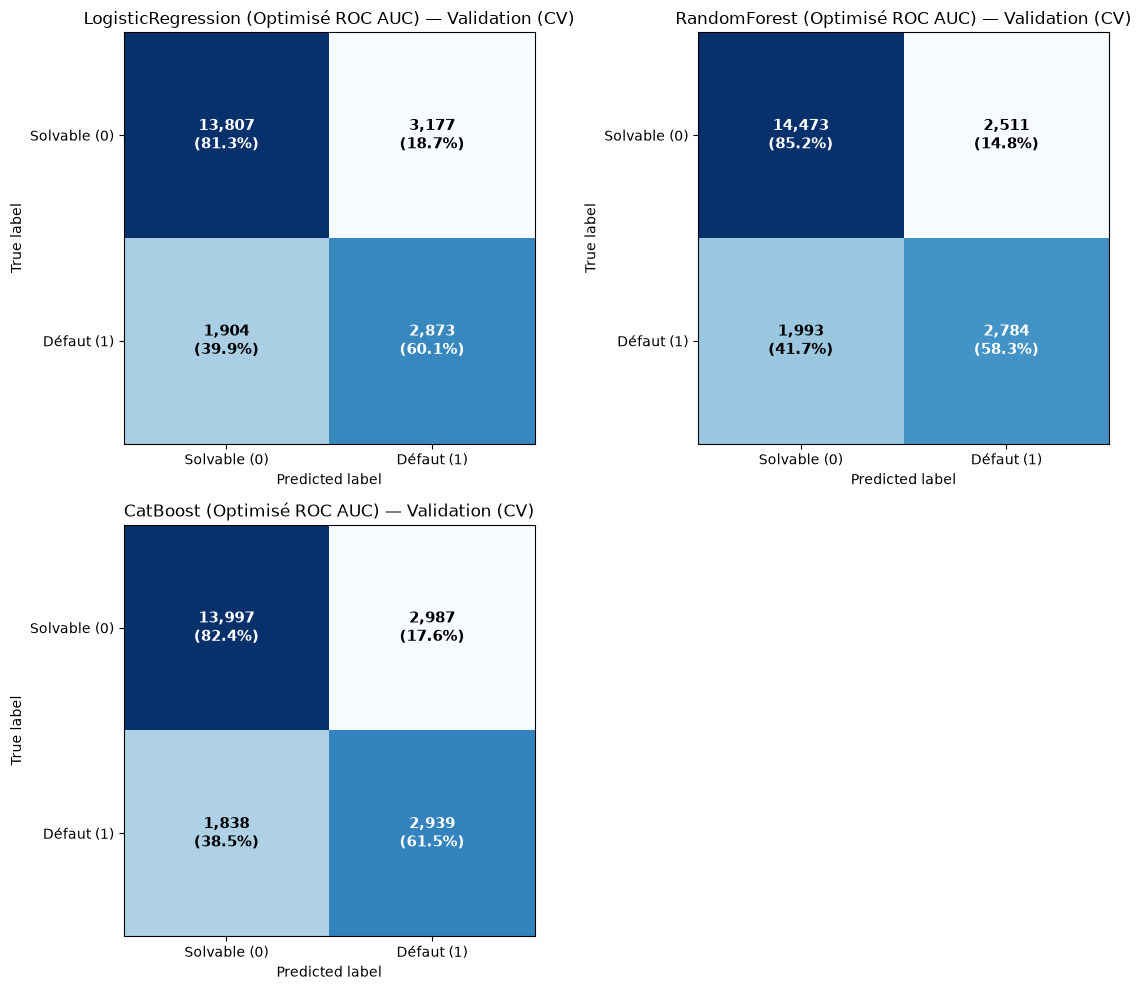


=== IMPORTANCE DES FEATURES (Optimisé F2-Score) ===
                          LogisticRegression  RandomForest  CatBoost  Moyenne (%)
PAY_1                                   7.95         27.98     33.51        23.14
PAY_2                                   1.29         15.28      2.22         6.26
PAY_3                                   2.33         11.20      4.07         5.87
EDUCATION_4                            13.69          0.00      0.97         4.89
PAY_4                                   2.39          8.32      2.58         4.43
LIMIT_BAL                               4.22          4.71      3.62         4.18
ratio_PAY_to_BILL_median                7.39          0.84      2.25         3.49
PAY_AMT1                                2.31          3.11      4.51         3.31
ratio_BILL_LIMIT1                       5.27          1.38      2.45         3.03
PAY_6                                   1.39          4.29      3.12         2.93
ratio_BILL_LIMIT2                       3.61 

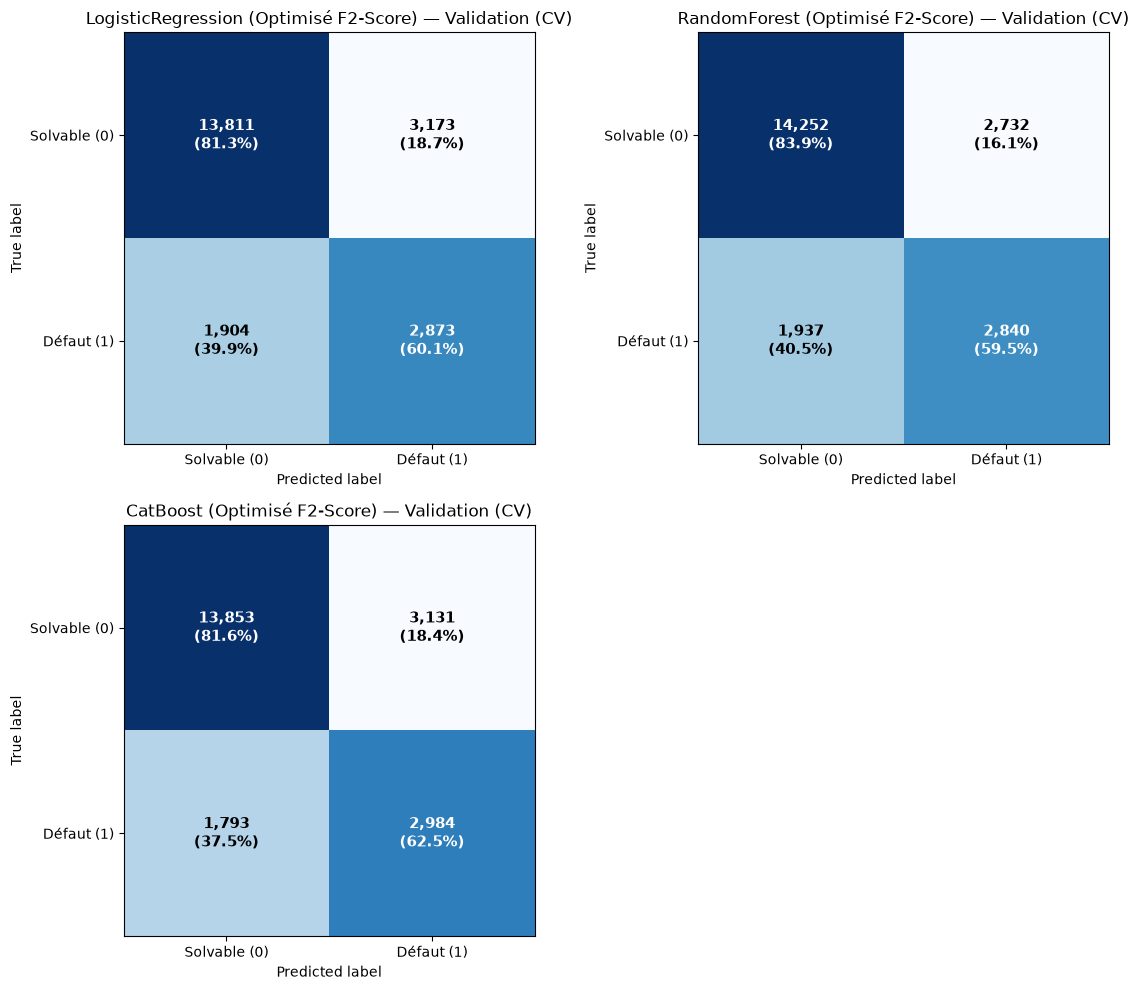

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict


def analyser_modeles(dict_modeles, titre_metric):
    # A. Importances de variables
    importances_dict = {}

    # 1. Extraction dynamique des vrais noms de features après transformation
    premier_pipeline = list(dict_modeles.values())[0]
    transformed_features = premier_pipeline[0].get_feature_names_out()
    clean_features = [
        f.replace("num__", "").replace("nom__", "").replace("ord__", "")
        for f in transformed_features
    ]

    for name, model in dict_modeles.items():
        clf = model[-1]

        if isinstance(clf, CalibratedClassifierCV):
            clf_estimator = (
                clf.calibrated_classifiers_[0].estimator
                if hasattr(clf, "calibrated_classifiers_")
                else clf.estimator
            )
        else:
            clf_estimator = clf

        if hasattr(clf_estimator, "feature_importances_"):
            raw_imp = clf_estimator.feature_importances_
        elif hasattr(clf_estimator, "coef_"):
            raw_imp = np.abs(clf_estimator.coef_[0])
        elif hasattr(clf_estimator, "coefs_"):
            raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
        else:
            continue

        total = raw_imp.sum()
        importances_dict[name] = (
            (raw_imp / total) * 100 if total > 0 else raw_imp
        )

    # 2. DataFrame construit avec le bon index (clean_features)
    df_imp = pd.DataFrame(importances_dict, index=clean_features)
    if not df_imp.empty:
        df_imp["Moyenne (%)"] = df_imp.mean(axis=1)
        df_imp = df_imp.sort_values(by="Moyenne (%)", ascending=False).round(2)

        print(f"\n=== IMPORTANCE DES FEATURES ({titre_metric}) ===")
        print(df_imp.to_string())

    # B. Matrices de confusion EN VALIDATION CROISÉE + Stockage des Rappels Validation
    #
    # Les modèles reçus (dict_modeles) sont déjà entraînés sur X_train en entier
    # (grid.best_estimator_), mais cross_validate/GridSearchCV ne conservent pas
    # les prédictions out-of-fold, seulement les scores agrégés. Pour afficher une
    # matrice de confusion représentative de la VALIDATION (et non un simple
    # rappel des données d'entraînement), on utilise cross_val_predict avec les
    # hyperparamètres déjà optimisés : chaque pli est prédit par un modèle qui ne
    # l'a jamais vu pendant son fit. Aucun nouvel entraînement final n'est refait
    # (pas de nouvelle recherche d'hyperparamètres) ; seul le refit par pli,
    # inhérent à toute validation croisée, a lieu ici.
    cv_cm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    n_models = len(dict_modeles)
    n_cols = 2 if n_models > 1 else 1
    n_rows = (n_models + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten() if n_models > 1 else [axes]

    recalls_val = {}

    for idx, (name, model) in enumerate(dict_modeles.items()):
        # Prédictions out-of-fold (validation croisée), pas sur X_train directement
        y_pred = cross_val_predict(
            model, X_train, y_train, cv=cv_cm, n_jobs=-1
        )
        cm = confusion_matrix(y_train, y_pred)

        # Taux de correspondance par classe réelle (ligne)
        cm_rate = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

        # Récupération directe du Recall Validation (Ligne 1, Colonne 1)
        recalls_val[name] = cm_rate[1, 1]

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm_rate,
            display_labels=["Solvable (0)", "Défaut (1)"],
        )
        disp.plot(
            cmap="Blues",
            ax=axes[idx],
            colorbar=False,
            include_values=False,
        )

        # Injection des valeurs : Effectif + %
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                rate = cm_rate[i, j]
                text_label = f"{count:,}\n({rate:.1%})"

                color = "white" if rate > 0.5 else "black"
                axes[idx].text(
                    j,
                    i,
                    text_label,
                    ha="center",
                    va="center",
                    color=color,
                    fontweight="bold",
                    fontsize=11,
                )

        axes[idx].set_title(f"{name} ({titre_metric}) — Validation (CV)")

    for idx in range(n_models, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    return recalls_val


# Exécution et récupération des rappels (calculés en validation croisée)
recalls_val_auc = analyser_modeles(best_models['roc_auc'], "Optimisé ROC AUC")
recalls_val_f2 = analyser_modeles(best_models['f2'], "Optimisé F2-Score")


MLPClassifier semble doué pour détecter les vrais clients solvables, ce qui n'est pas le but recherché ici, il ne peut pas compenser via un hyperparamètre le déséquilibre de classe, on pourrait lui diminuer le seuil de décision ou faire un entrainement particulier compute_sample_weight pour compenser le déséquilibre

## Test final sur X_test

In [22]:
import numpy as np
import pandas as pd
from sklearn.metrics import fbeta_score, recall_score, roc_auc_score

print("=== ÉVALUATION FINALE MULTI-TABLEAUX (X_TEST VS VALIDATION CV POST-TUNING) ===\n")


def generer_tableaux_analyse(
    dict_best_models, df_cv_results, dict_recalls_val, metric_name
):
    # df_cv_results est indexé par 'Modèle' et contient la colonne 'Score Val'
    # = score de VALIDATION croisée du meilleur jeu d'hyperparamètres (post-tuning,
    # cellule GridSearchCV), et non un score d'entraînement.
    cv_map = df_cv_results
    score_col = "Score Val"

    target_rows = []
    recall_rows = []

    for model_name, model in dict_best_models.items():
        # 1. Prédictions sur X_test
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        # 2. Métriques sur Test
        test_target = (
            roc_auc_score(y_test, y_pred_proba)
            if metric_name == "ROC AUC"
            else fbeta_score(y_test, y_pred, beta=2)
        )
        test_recall = recall_score(y_test, y_pred)

        # 3. Récupération du score de Validation CV (post-tuning) et du Recall Validation
        cv_target = cv_map.loc[model_name, score_col]
        val_recall = dict_recalls_val.get(model_name, np.nan)

        # 4. Calcul des écarts (Test vs Validation CV, plus Train vs Validation)
        diff_target = test_target - cv_target
        diff_recall = (
            (test_recall - val_recall) if pd.notna(val_recall) else np.nan
        )

        # Diagnostics
        diag_target = (
            "⚠️ Overfit important !" if diff_target < -0.10 else
            "⚠️ Overfit" if diff_target < -0.05 else
            "léger Overfit" if diff_target < -0.02 else
            "📈 Sous-estimé" if diff_target > 0.02 else
            "✅ Stable"
        )
        diag_recall = (
            "⚠️ baisse Rappel"
            if pd.notna(diff_recall) and diff_recall < -0.02
            else "✅ Stable"
        )

        # Tableau 1 : Métrique Cible (Validation CV vs Test)
        target_rows.append({
            "Modèle": model_name,
            f"{metric_name} (Val CV)": round(cv_target, 4),
            f"{metric_name} (Test)": round(test_target, 4),
            "Diff Target": round(diff_target, 4),
            "Diagnostic": diag_target,
        })

        # Tableau 2 : Métrique Rappel (Validation CV vs Test)
        recall_rows.append({
            "Modèle": model_name,
            "Recall (Val CV)": (
                round(val_recall, 4) if pd.notna(val_recall) else "N/A"
            ),
            "Recall (Test)": round(test_recall, 4),
            "Diff Recall": (
                round(diff_recall, 4) if pd.notna(diff_recall) else "N/A"
            ),
            "Diagnostic": diag_recall,
        })

    return pd.DataFrame(target_rows), pd.DataFrame(recall_rows)


# ---------------------------------------------------------
# A. BLOC OPTIMISÉ POUR F2-SCORE
# ---------------------------------------------------------
df_f2_target, df_f2_recall = generer_tableaux_analyse(
    best_models['f2'], df_grid_f2, recalls_val_f2, "F2 Score"
)

print("=" * 65)
print("🎯 1. OPTIMISATION : F2-SCORE")
print("=" * 65)

print("\n--- Tableau 1A : Stabilité Métrique Cible (F2-Score, Val CV vs Test) ---")
print(df_f2_target.to_string(index=False))

print("\n--- Tableau 1B : Dérive du Rappel (Recall Val CV vs Test) ---")
print(df_f2_recall.to_string(index=False))

print("\n\n")

# ---------------------------------------------------------
# B. BLOC OPTIMISÉ POUR ROC AUC
# ---------------------------------------------------------
df_auc_target, df_auc_recall = generer_tableaux_analyse(
    best_models['roc_auc'], df_grid_auc, recalls_val_auc, "ROC AUC"
)

print("=" * 65)
print("🎯 2. OPTIMISATION : ROC AUC")
print("=" * 65)

print("\n--- Tableau 2A : Stabilité Métrique Cible (ROC AUC, Val CV vs Test) ---")
print(df_auc_target.to_string(index=False))

print("\n--- Tableau 2B : Dérive du Rappel (Recall Val CV vs Test) ---")
print(df_auc_recall.to_string(index=False))

=== ÉVALUATION FINALE MULTI-TABLEAUX (X_TEST VS VALIDATION CV POST-TUNING) ===

🎯 1. OPTIMISATION : F2-SCORE

--- Tableau 1A : Stabilité Métrique Cible (F2-Score, Val CV vs Test) ---
            Modèle  F2 Score (Val CV)  F2 Score (Test)  Diff Target    Diagnostic
LogisticRegression             0.5711           0.5868       0.0157      ✅ Stable
      RandomForest             0.5754           0.6022       0.0268 📈 Sous-estimé
          CatBoost             0.5915           0.6090       0.0175      ✅ Stable

--- Tableau 1B : Dérive du Rappel (Recall Val CV vs Test) ---
            Modèle  Recall (Val CV)  Recall (Test)  Diff Recall Diagnostic
LogisticRegression           0.6014         0.6176       0.0161   ✅ Stable
      RandomForest           0.5945         0.6176       0.0231   ✅ Stable
          CatBoost           0.6247         0.6393       0.0147   ✅ Stable



🎯 2. OPTIMISATION : ROC AUC

--- Tableau 2A : Stabilité Métrique Cible (ROC AUC, Val CV vs Test) ---
            Modèle  RO

Classification des modèles  
Choix du meilleur modèle selon : Moyenne de (F2 Score & AUC ROC)
Enregistrement du meilleur modèle

=== SCORE MAÎTRE, PODIUM ET SAUVEGARDE DU MEILLEUR MODÈLE ===

--- PODIUM COMPLET (6 candidats, triés par Score Maître) ---
          Candidat  F2 (Val CV)  ROC AUC (Val CV)  Recall (Val CV)  Score Maître
          CatBoost       0.5915            0.7855           0.6247        0.6885
      RandomForest       0.5754            0.7824           0.5945        0.6789
LogisticRegression       0.5711            0.7534           0.6014        0.6622

🏆 PODIUM — TOP 3
🥇 CatBoost — Score Maître : 0.6885
🥈 RandomForest — Score Maître : 0.6789
🥉 LogisticRegression — Score Maître : 0.6622

>>> Meilleur modèle retenu : CatBoost

--- RÉCAPITULATIF DES MÉTRIQUES : CatBoost ---
Métrique  Val CV   Test  Écart (Test - Val CV)
      F2  0.5915 0.6090                 0.0175
 ROC AUC  0.7855 0.8030                 0.0175
  Recall  0.6247 0.6393                 0.0146


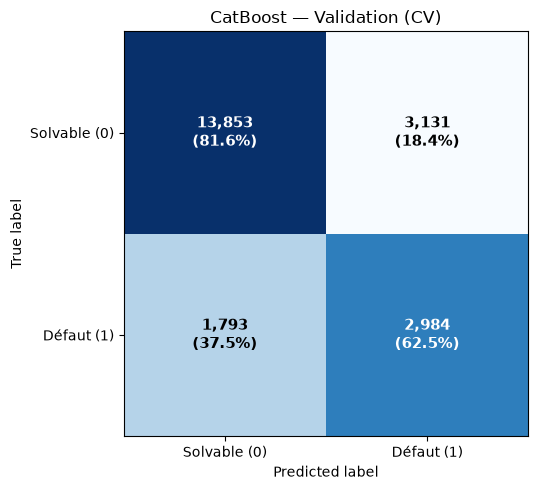


✅ Modèle sauvegardé : c:\Users\johan\VS Code Wild 2\PROJET_DEFAULT_CREDIT_CARD_ML\lab_ML\corrections_niveau3\best_models\model_S126_corrections_niveau3.joblib


In [23]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate

print("=== SCORE MAÎTRE, PODIUM ET SAUVEGARDE DU MEILLEUR MODÈLE ===\n")

# 1. Scorer F2 et grille de CV (mêmes paramètres que tout le notebook)
f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Regroupement des 6 candidats (1 pipeline par famille de modèle)
candidates = best_models['f2']

# 3. Ré-évaluation homogène des 6 candidats sur F2 + ROC AUC
#    (mêmes 5 plis pour tout le monde, aucun refit d'hyperparamètres)
podium_rows = []
for label, pipeline in candidates.items():
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={'f2': f2_scorer, 'roc_auc': 'roc_auc', 'recall': 'recall'},
        n_jobs=-1,
    )
    f2_val = np.mean(cv_scores['test_f2'])
    auc_val = np.mean(cv_scores['test_roc_auc'])
    recall_val = np.mean(cv_scores['test_recall'])

    podium_rows.append({
        "Candidat": label,
        "F2 (Val CV)": round(f2_val, 4),
        "ROC AUC (Val CV)": round(auc_val, 4),
        "Recall (Val CV)": round(recall_val, 4),
        "Score Maître": round((f2_val + auc_val) / 2, 4),
    })

# Tri par Score Maître (Remplacer by="Recall (Val CV)" si vous préférez privilégier le Recall pur)
df_podium = pd.DataFrame(podium_rows).sort_values(
    by="Score Maître", ascending=False
).reset_index(drop=True)

print("--- PODIUM COMPLET (6 candidats, triés par Score Maître) ---")
print(df_podium.to_string(index=False))

# 4. Top 3
print("\n" + "=" * 65)
print("🏆 PODIUM — TOP 3")
print("=" * 65)
for rank, row in df_podium.head(3).iterrows():
    medaille = ["🥇", "🥈", "🥉"][rank]
    print(f"{medaille} {row['Candidat']} — Score Maître : {row['Score Maître']}")

# 5. Sélection du meilleur candidat et récupération du pipeline + métadonnées
best_label = df_podium.iloc[0]["Candidat"]
best_pipeline = candidates[best_label]
best_model_name = best_label
best_direction = "f2"

print(f"\n>>> Meilleur modèle retenu : {best_label}")

# 6. Récap complet des métriques du meilleur modèle : Val CV vs Test
y_pred_proba_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = best_pipeline.predict(X_test)

recap_best = pd.DataFrame([
    {
        "Métrique": "F2",
        "Val CV": df_podium.iloc[0]["F2 (Val CV)"],
        "Test": round(fbeta_score(y_test, y_pred_test, beta=2), 4),
    },
    {
        "Métrique": "ROC AUC",
        "Val CV": df_podium.iloc[0]["ROC AUC (Val CV)"],
        "Test": round(roc_auc_score(y_test, y_pred_proba_test), 4),
    },
    {
        "Métrique": "Recall",
        "Val CV": df_podium.iloc[0]["Recall (Val CV)"],
        "Test": round(recall_score(y_test, y_pred_test), 4),
    }
])
recap_best["Écart (Test - Val CV)"] = (
    recap_best["Test"] - recap_best["Val CV"]
).round(4)

print(f"\n--- RÉCAPITULATIF DES MÉTRIQUES : {best_label} ---")
print(recap_best.to_string(index=False))

# 7. Matrice de confusion du meilleur modèle, en validation croisée
#    (out-of-fold, même logique que la cellule d'analyse des modèles)
y_pred_cv_best = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, n_jobs=-1)
cm_best = confusion_matrix(y_train, y_pred_cv_best)
cm_best_rate = cm_best.astype("float") / cm_best.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_rate, display_labels=["Solvable (0)", "Défaut (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False, include_values=False)

for i in range(2):
    for j in range(2):
        count = cm_best[i, j]
        rate = cm_best_rate[i, j]
        color = "white" if rate > 0.5 else "black"
        ax.text(
            j, i, f"{count:,}\n({rate:.1%})",
            ha="center", va="center", color=color, fontweight="bold", fontsize=11,
        )

ax.set_title(f"{best_label} — Validation (CV)")
plt.tight_layout()
plt.show()

# 8. Sauvegarde du meilleur modèle en joblib
niveau_correction = Path.cwd().name  # nom du dossier courant du notebook

output_dir = Path.cwd() / "best_models"
output_dir.mkdir(exist_ok=True)

filename = f"model_S{numero_scenario}_{niveau_correction}.joblib"
output_path = output_dir / filename

joblib.dump(best_pipeline, output_path)
print(f"\n✅ Modèle sauvegardé : {output_path}")